# Machine Learning avancé — Jour 3
## Classes rares, calibration et feature engineering

**Objectifs de la séance**

1. Distinguer score de ranking, probabilité calibrée et décision par seuil.
2. Comparer une baseline, `class_weight` et SMOTE sans fuite de données.
3. Calibrer un modèle avec des prédictions hors pli.
4. Construire et auditer des variables, puis démontrer leur utilité par ablation.

> Règle directrice : le test final reste fermé jusqu’à la toute fin. Toute opération qui apprend des données — imputation, encodage, sampling, sélection, calibration — vit dans le pipeline ou dans le train du pli.

In [ ]:
# Exécuter une seule fois si nécessaire dans Colab
# !pip -q install imbalanced-learn category_encoders

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             brier_score_loss, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectFromModel

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option('display.max_columns', 50)

## 1. Jeu de données pédagogique

Nous simulons une campagne où seuls environ 8 % des clients souscrivent. Le jeu contient :
- des variables numériques avec asymétrie et valeurs manquantes ;
- des catégories, dont certaines rares ;
- une variable temporelle synthétique ;
- une colonne volontairement interdite : `duration_after_call`, connue **après** la décision d’appeler.

In [ ]:
X_num, y = make_classification(
    n_samples=5000, n_features=6, n_informative=4, n_redundant=1,
    weights=[0.92, 0.08], class_sep=0.9, flip_y=0.02, random_state=RANDOM_STATE
)

df = pd.DataFrame(X_num, columns=['age_proxy', 'income_signal', 'contact_history',
                                  'macro_context', 'campaign_pressure', 'noise'])
df['income_eur'] = np.exp(10.1 + 0.55 * df['income_signal']).clip(1000, 250000)
df['previous_contacts'] = np.maximum(0, np.round(2 + 2 * df['contact_history'])).astype(int)
df['days_since_contact'] = np.where(df['previous_contacts'].eq(0), 999,
                                    rng.integers(1, 365, len(df)))
df['job'] = rng.choice(['admin', 'technician', 'services', 'student', 'retired'],
                       size=len(df), p=[.30, .25, .22, .10, .13])
df['channel'] = rng.choice(['phone', 'mobile', 'web'], size=len(df), p=[.55, .35, .10])
df['month'] = rng.choice(['mar', 'apr', 'may', 'jun', 'jul'], size=len(df))
df.loc[rng.random(len(df)) < .08, 'income_eur'] = np.nan
# À exclure : information connue seulement une fois l'appel terminé
df['duration_after_call'] = np.maximum(0, 80 + 120*y + rng.normal(0, 35, len(df)))

X = df.drop(columns='duration_after_call')
print('Prévalence positive :', f'{y.mean():.1%}')
print('Dimensions :', X.shape)
X.head()

## 2. Split avant toute décision

On réserve 20 % des observations pour le test final. Le split est stratifié afin de conserver approximativement la prévalence de la classe positive. **Le jeu test ne sert ni au choix du modèle, ni au seuil, ni à la calibration.**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Train : {len(X_train)} lignes — prévalence {y_train.mean():.2%}')
print(f'Test  : {len(X_test)} lignes — prévalence {y_test.mean():.2%}')

num_cols = ['age_proxy', 'income_signal', 'contact_history', 'macro_context',
            'campaign_pressure', 'noise', 'income_eur', 'previous_contacts', 'days_since_contact']
cat_cols = ['job', 'channel', 'month']

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median', add_indicator=True)),
        ('scale', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)
])

def make_logit(class_weight=None):
    return Pipeline([
        ('prep', preprocess),
        ('model', LogisticRegression(max_iter=2000, class_weight=class_weight, random_state=RANDOM_STATE))
    ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 3. Baseline et déséquilibre

L’accuracy est souvent insuffisante avec une classe rare : prédire toujours « non » peut obtenir un score élevé tout en ne détectant aucun positif. Nous comparons ici des modèles avec l’**Average Precision (AP)**, qui évalue la qualité du classement des positifs, et le Brier score, qui évalue la qualité probabiliste (plus petit est meilleur).

In [ ]:
from sklearn.dummy import DummyClassifier

models = {
    'Dummy prior': Pipeline([('prep', preprocess), ('model', DummyClassifier(strategy='prior'))]),
    'Logistique': make_logit(),
    'Logistique pondérée': make_logit(class_weight='balanced')
}
rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, n_jobs=-1,
                            scoring={'ap': 'average_precision', 'brier': 'neg_brier_score'})
    rows.append({'modèle': name, 'AP moyenne': scores['test_ap'].mean(),
                 'AP écart-type': scores['test_ap'].std(),
                 'Brier moyen': -scores['test_brier'].mean()})
results = pd.DataFrame(rows).sort_values('AP moyenne', ascending=False)
results.style.format({'AP moyenne': '{:.3f}', 'AP écart-type': '{:.3f}', 'Brier moyen': '{:.3f}'})

### Question

Pourquoi un modèle pondéré peut-il améliorer le rappel ou l’AP, tout en dégradant la calibration brute de ses probabilités ? Écrivez votre réponse avant d’exécuter la suite.

## 4. SMOTE : uniquement dans le train de chaque pli

SMOTE fabrique des points synthétiques entre voisins minoritaires. Il faut l’appliquer **après le split** et **à l’intérieur de chaque pli d’entraînement** ; sinon des observations synthétiques trop proches peuvent contaminer la validation. Pour cela, on utilise `imblearn.pipeline.Pipeline`, et non la pipeline scikit-learn standard.

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_model = ImbPipeline([
    ('prep', preprocess),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

smote_scores = cross_validate(smote_model, X_train, y_train, cv=cv, n_jobs=-1,
                               scoring={'ap': 'average_precision', 'brier': 'neg_brier_score'})
pd.DataFrame([{
    'modèle': 'Logistique + SMOTE',
    'AP moyenne': smote_scores['test_ap'].mean(),
    'AP écart-type': smote_scores['test_ap'].std(),
    'Brier moyen': -smote_scores['test_brier'].mean()
}]).style.format({'AP moyenne': '{:.3f}', 'AP écart-type': '{:.3f}', 'Brier moyen': '{:.3f}'})

## 5. Ranking, calibration, décision

Ces trois objets sont différents :

- **Ranking** : l’ordre des clients, évalué par AP ou courbe précision-rappel.
- **Calibration** : une prédiction de 0,80 doit correspondre à environ 80 % de positifs dans un groupe comparable.
- **Décision** : une règle d’action transforme une probabilité en oui/non selon les coûts et la capacité opérationnelle.

Une amélioration sur l’un ne garantit pas une amélioration sur les deux autres.

In [ ]:
base = make_logit(class_weight='balanced')
base.fit(X_train, y_train)
p_test_raw = base.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PrecisionRecallDisplay.from_predictions(y_test, p_test_raw, ax=axes[0], name='pondéré')
axes[0].axhline(y_test.mean(), ls='--', color='grey', label='prévalence')
axes[0].legend()
CalibrationDisplay.from_predictions(y_test, p_test_raw, n_bins=10, strategy='quantile', ax=axes[1], name='pondéré')
axes[1].set_title('Calibration sur test — diagnostic final')
plt.tight_layout()
print('AP test :', round(average_precision_score(y_test, p_test_raw), 3))
print('Brier test :', round(brier_score_loss(y_test, p_test_raw), 3))

## 6. Calibration sans fuite

`CalibratedClassifierCV` produit des prédictions hors pli pour apprendre la transformation de calibration. La calibration est donc apprise sans utiliser le label de l’observation prédite par le modèle de base.

- `sigmoid` : plus contraint, souvent préférable avec peu de données ;
- `isotonic` : plus flexible, mais plus susceptible de surapprendre si l’échantillon de calibration est limité.

In [ ]:
calibrated = CalibratedClassifierCV(
    estimator=make_logit(class_weight='balanced'), method='sigmoid', cv=5
)
calibrated.fit(X_train, y_train)
p_test_cal = calibrated.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
CalibrationDisplay.from_predictions(y_test, p_test_raw, n_bins=10, strategy='quantile', ax=ax, name='brut pondéré')
CalibrationDisplay.from_predictions(y_test, p_test_cal, n_bins=10, strategy='quantile', ax=ax, name='sigmoïde calibrée')
ax.set_title('Comparer les probabilités')
plt.tight_layout()

pd.DataFrame({
    'modèle': ['brut pondéré', 'calibré sigmoid'],
    'AP test': [average_precision_score(y_test, p_test_raw), average_precision_score(y_test, p_test_cal)],
    'Brier test': [brier_score_loss(y_test, p_test_raw), brier_score_loss(y_test, p_test_cal)]
}).style.format({'AP test': '{:.3f}', 'Brier test': '{:.3f}'})

## 7. Choisir un seuil avec des coûts

Sous hypothèses simples — probabilités calibrées, coût des décisions correctes nul, coûts fixes — le seuil théorique est 
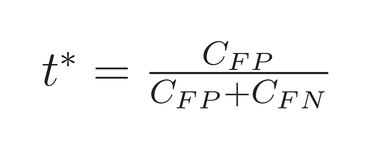

Mais en pratique, il faut aussi respecter une capacité, par exemple « au plus 100 appels aujourd’hui ». Le seuil se choisit sur une validation dédiée ou via CV, **jamais 
en pilotant le test final**.

In [ ]:
# Démonstration pédagogique uniquement : on utilise ici le test après l'avoir explicitement ouvert.
# Dans un vrai projet, cette cellule serait exécutée sur validation, puis le test ne serait ouvert qu'une seule fois.
C_FP, C_FN = 1, 5
thresholds = np.linspace(0.01, .99, 99)
records = []
for t in thresholds:
    pred = (p_test_cal >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    records.append({'seuil': t, 'coût': C_FP*fp + C_FN*fn, 'alertes': int(pred.sum()),
                    'precision': tp/(tp+fp) if tp+fp else 0, 'recall': tp/(tp+fn) if tp+fn else 0})
threshold_table = pd.DataFrame(records)
best = threshold_table.loc[threshold_table['coût'].idxmin()]
print('Seuil théorique :', round(C_FP/(C_FP+C_FN), 3))
print('Meilleur seuil observé :', best['seuil'].round(2), '| coût :', int(best['coût']), '| alertes :', int(best['alertes']))
plt.figure(figsize=(8,4))
plt.plot(threshold_table['seuil'], threshold_table['coût'])
plt.axvline(best['seuil'], color='tab:red', ls='--', label=f"minimum = {best['seuil']:.2f}")
plt.xlabel('Seuil'); plt.ylabel('Coût total'); plt.legend(); plt.tight_layout()

## 8. Features : produire un signal défendable

Avant une transformation, documentez : **formule, unité, disponibilité temporelle, traitement des cas limites et hypothèse métier**.

Nous créons ici deux features sûres :
- `had_previous_contact` : sépare la sentinelle `999` d’un vrai nombre de jours ;
- `log_income` : compresse une variable très asymétrique tout en acceptant zéro grâce à `log1p`.

La feature interdite `duration_after_call` reste exclue : elle est inconnue avant l’appel.

In [ ]:
def add_features(frame):
    out = frame.copy()
    out['had_previous_contact'] = (out['days_since_contact'] != 999).astype(int)
    out['days_since_contact_clean'] = out['days_since_contact'].replace(999, np.nan)
    out['log_income'] = np.log1p(out['income_eur'].clip(lower=0))
    out['contacts_per_known_day'] = out['previous_contacts'] / (1 + out['days_since_contact_clean'].fillna(365))
    return out

Xf_train, Xf_test = add_features(X_train), add_features(X_test)
new_num_cols = num_cols + ['had_previous_contact', 'days_since_contact_clean', 'log_income', 'contacts_per_known_day']
feature_preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)), ('scale', StandardScaler())]), new_num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])
feature_model = Pipeline([('prep', feature_preprocess), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
feature_model.fit(Xf_train, y_train)
print('AP avec features :', round(average_precision_score(y_test, feature_model.predict_proba(Xf_test)[:,1]), 3))

## 9. Ablation et importance par permutation

Une feature n’est pas validée parce qu’elle paraît intuitive. On compare le même protocole **avec et sans une famille de variables**. L’importance par permutation mesure ensuite la baisse de score quand on casse aléatoirement une colonne ; elle reste une mesure conditionnelle aux autres features, donc des variables corrélées peuvent se partager leur importance.

In [ ]:
perm = permutation_importance(feature_model, Xf_test, y_test, scoring='average_precision',
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=Xf_test.columns).sort_values()
importance.tail(12).plot.barh(figsize=(8, 5), title='Importance par permutation — AP')
plt.xlabel('Baisse moyenne de l’AP après permutation')
plt.tight_layout()
importance.sort_values(ascending=False).head(10)

## 10. Exercices de fin de séance

1. Remplacez `class_weight='balanced'` par un ratio de poids métier et comparez AP, Brier et volume d’alertes.
2. Comparez `sigmoid` et `isotonic`. Quelle méthode choisiriez-vous si vous disposez de seulement 500 exemples de calibration ?
3. Ajoutez une interaction métier justifiée, puis vérifiez son gain par ablation dans une CV.
4. Proposez un target encoding pour `job` : expliquez exactement où le cross-fitting doit être placé.
5. Expliquez pourquoi équilibrer le jeu de test fausserait l’évaluation de la précision, du coût et de la calibration.

## Checklist de livraison

- [ ] Le split respecte-t-il groupes et temps, si ces structures existent ?
- [ ] Le sampler est-il appliqué seulement au train de chaque pli ?
- [ ] Le modèle est-il comparé à une baseline ?
- [ ] La calibration est-elle apprise hors pli ?
- [ ] Le seuil dépend-il de coûts et de capacité documentés ?
- [ ] Chaque feature est-elle disponible à l’instant de décision ?
- [ ] Le test a-t-il été ouvert une seule fois, après les choix ?